# Three Steps MultiFidelity Neural Network

In [41]:

#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.callbacks import ModelCheckpoint
# import warnings
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from keras.models import save_model
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, import_data, normalization
from time import perf_counter
import pandas
import pickle
import os
from itertools import product
import keras
import tensorflow as tf



In [42]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data preparation

In [43]:
file_path_D = os.path.join("..", "..", "Diffusion\DATA", "Discretizations_time.txt")
file_path_diff = os.path.join("..", "..", "Diffusion\DATA", "Discretizations.txt")

Discretizations= np.loadtxt(
    file_path_D
).astype(
    int
)

#Discr= np.loadtxt(
#    file_path_diff
#).astype(
#    int
#)
Discr=np.array([46])

In [44]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_HF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_HF.mat")
(reaction_HF_test, U_HF_test, t_HF_test) = import_data(file_path_HF)
t_HF_test=t_HF_test.T
U_HF_test = U_HF_test[:, :, 44,44]

In [45]:
########################     NORMALIZATION  #########################
# Input

reaction_HF_test = normalization(reaction_HF_test)
t_HF_test=normalization(t_HF_test)
U_HF_test=normalization(U_HF_test)

In [46]:
#########################     TRAIN SET      ##########################
NepoLF = 1000  # number of epochs for first NN: NN_LF
NepoLin=1000
NepoHF = 1000  # number of epochs for second NN: NN_HF

Nlf=200
n_HF=100


In [47]:

# TRANSFORMATION

permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(t_HF_test))

reaction_HF = reaction_HF_test[permutation1][0:n_HF]
t_HF = t_HF_test[permutation2][0:n_HF]

grid1, grid2 = np.meshgrid(reaction_HF, t_HF)
reaction_HF = np.column_stack((grid1.ravel(), grid2.ravel()))
reaction_HF_test = np.array(list(product(reaction_HF_test.flatten(), t_HF_test.flatten())))

reaction_HF=np.c_[reaction_HF, np.abs(np.sin(3.5*np.pi*reaction_HF[:, 1])),np.ones(reaction_HF.shape[0])]
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(3.5*np.pi*reaction_HF_test[:, 1])),np.ones(reaction_HF_test.shape[0])]

##
p1, p2 = np.meshgrid(permutation1[0:n_HF], permutation2[0:n_HF])
permutation = np.column_stack((p1.ravel(), p2.ravel()))
U_HF = U_HF_test[permutation[:,0],permutation[:,1]] 
row, col = U_HF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test = U_HF_test.flatten()[comb]
##


In [48]:
U_LF_list = []
U_Lin_list = []
U_HF_list = []


r2_HF_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores LF R^2
r2_Lin_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])
mse_HF_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores LF MSE
mse_Lin_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])


## Neural Network
Cycle on the Discretization and the value of the diffusion

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************


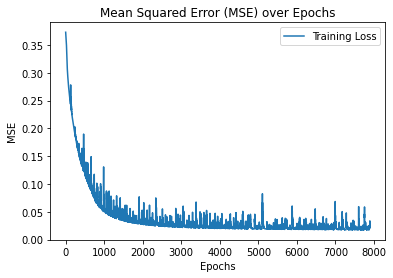

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.0887521039226971
R^2: 0.28760190834076516
1/1 [==============================] - 0s 66ms/step


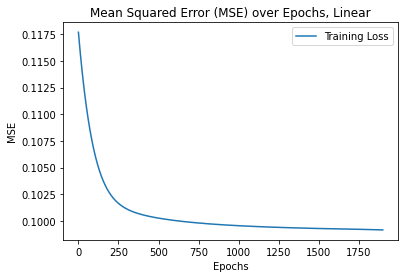

2/2 [==============================] - 0s 0s/step


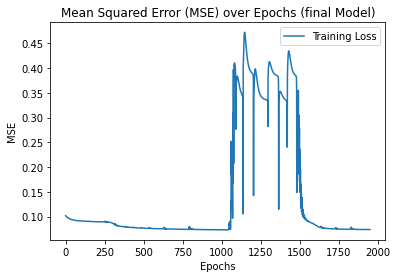

2/2 [==============================] - 0s 0s/step
Elapsed time:  23.949519299902022
2/2 [==============================] - 0s 5ms/step

Lin Model:
Test MSE: 0.12335599897627823
R^2: -0.08972898253453532

HF Model:
Test MSE: 0.12233277928817421
R^2: -0.08068984249367417
2/2 [==============================] - 0s 3ms/step


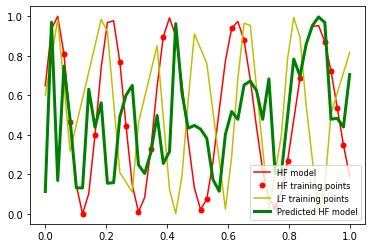

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************


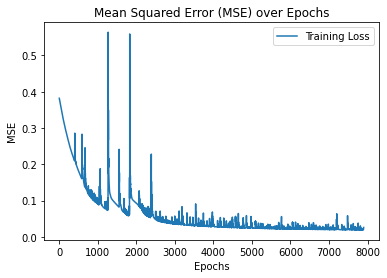

2/2 [==============================] - 0s 16ms/step

LF Model:
Test MSE: 0.24114256494354777
R^2: -1.1197180564581197
1/1 [==============================] - 0s 26ms/step


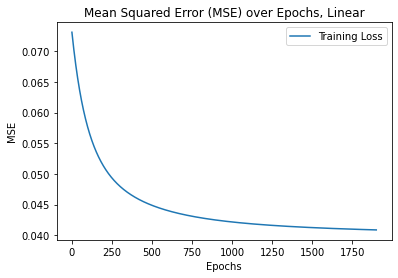

2/2 [==============================] - 0s 3ms/step


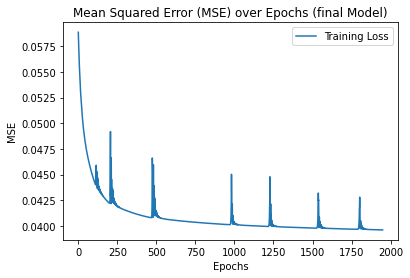

2/2 [==============================] - 0s 0s/step
Elapsed time:  22.728375900071114
2/2 [==============================] - 0s 16ms/step

Lin Model:
Test MSE: 0.1109244592251018
R^2: 0.02009145000877577

HF Model:
Test MSE: 0.1067971877636314
R^2: 0.05655183594604074
2/2 [==============================] - 0s 4ms/step


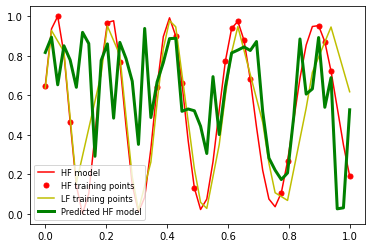

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************


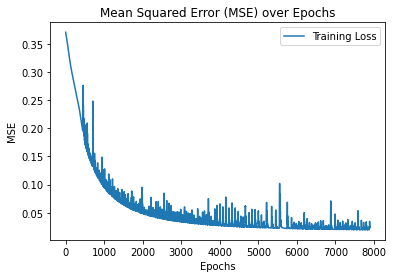

2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.2203064801006815
R^2: -0.870361182541501
1/1 [==============================] - 0s 31ms/step


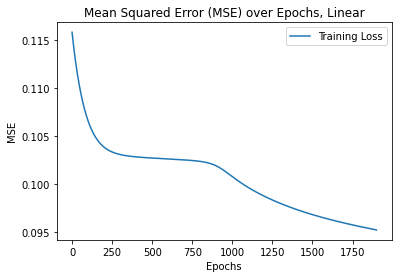

2/2 [==============================] - 0s 9ms/step


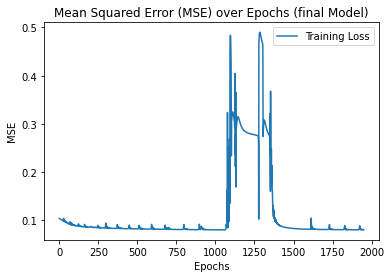

2/2 [==============================] - 0s 0s/step
Elapsed time:  23.22741789999418
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.11063288975532526
R^2: 0.022667179639069834

HF Model:
Test MSE: 0.13400338947038049
R^2: -0.18378821034734072
2/2 [==============================] - 0s 3ms/step


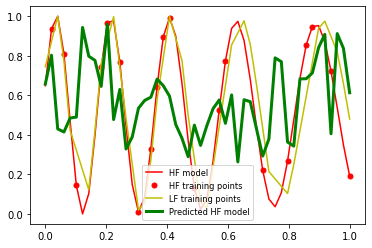

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************


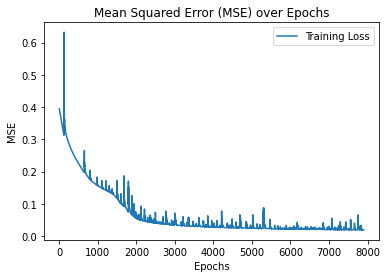

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.1370959586922066
R^2: -0.18436374088504914
1/1 [==============================] - 0s 34ms/step


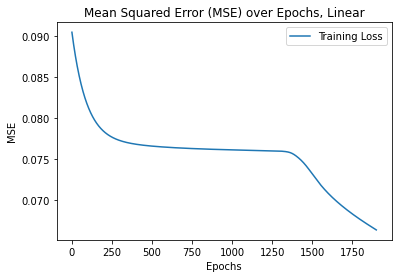

2/2 [==============================] - 0s 3ms/step


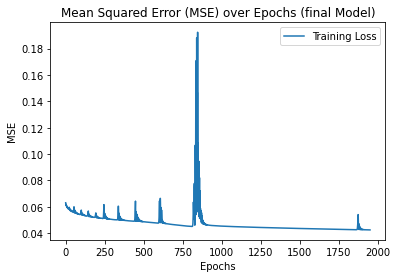

2/2 [==============================] - 0s 4ms/step
Elapsed time:  22.90326049993746
2/2 [==============================] - 0s 17ms/step

Lin Model:
Test MSE: 0.10081632461173587
R^2: 0.10938688224522197

HF Model:
Test MSE: 0.11264090204950673
R^2: 0.004928365050279493
2/2 [==============================] - 0s 3ms/step


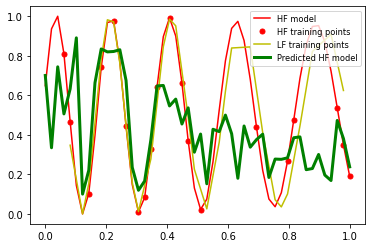

  Discretization Diffusion       R2  diffusion
0             46       NaN -0.08069        0.0
1             46       NaN  0.05655        5.0
2             46       NaN -0.18379       75.0
3             46       NaN  0.00493        1.0
  Discretization Diffusion      MSE  diffusion
0             46       NaN  0.12233        0.0
1             46       NaN  0.10680        5.0
2             46       NaN  0.13400       75.0
3             46       NaN  0.11264        1.0


In [49]:
#checkpoint = ModelCheckpoint("best_model_3NN.h5", monitor="val_loss", save_best_only=True)
test_mse_HF_list = []
test_mse_LF_list = []
test_mse_Lin_list = []
diffusion=[5]
r2_HF_list = []
r2_LF_list = []
r2_Lin_list = []
Discretizations=[Discretizations[-1]]
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):    # Loop over the range of the number of basis functions
        file_name= os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_LF_46"+"_d"+str(diffusion[d])+"_t"+str(Discretizations[m])+".mat")
        #file_name="Diffusion\DATA\reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test, t_LF_test) = import_data(file_name)
        t_LF_test=t_LF_test.T
        
        U_LF_test = U_LF_test[
        :,
        :,
        int(4*(Discretizations[m]-1)/9),
        int(4*(Discretizations[m]-1)/9)
        ]
        
        reaction_LF_test = normalization(reaction_LF_test)
        t_LF_test = normalization(t_LF_test)
        U_LF_test = normalization(U_LF_test)
                
        print(
            f"********************  # Nb. nodes = {t_LF_test.shape[0]}  ********************"
            )
            
        ######### DATASET
        L=np.minimum(Nlf,t_LF_test.shape[0])
        permutation1 = np.random.permutation(len(reaction_LF_test))
        permutation2 = np.random.permutation(len(t_LF_test))
        reaction_LF = reaction_LF_test[permutation1][0:L]    # problema di consistenza qui: non stai confrontando stesso numero di dati, ma è cosairreparabile se non creando nuovo dataset
        t_LF = t_LF_test[permutation2][0:L]
          
        grid1, grid2 = np.meshgrid(reaction_LF, t_LF)
        reaction_LF = np.column_stack((grid1.ravel(), grid2.ravel()))   # <--------
        reaction_LF_test = np.array(list(product(reaction_LF_test.flatten(), t_LF_test.flatten())))
          
        #
        reaction_LF=np.c_[reaction_LF, np.abs(np.sin(3.5*np.pi*reaction_LF[:, 1])),np.ones(reaction_LF.shape[0])]
        reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(3.5*np.pi*reaction_LF_test[:, 1])),np.ones(reaction_LF_test.shape[0])]
        #
            
        p1, p2 = np.meshgrid(permutation1[0:L], permutation2[0:L])
        permutation = np.column_stack((p1.ravel(), p2.ravel()))
        U_train_LF = U_LF_test[permutation[:,0],permutation[:,1]]
        row, col = U_LF_test.shape
        index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
        comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
        U_LF_test = U_LF_test.flatten()[comb]
        #######      
        print(
           f"********************  # Diff: = {diffusion[d]}  ********************"
           )
        
       ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        }

        
        modelLF = getModel(bestLF_params, "LF")

        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        plt.plot(modelLF.history.history['loss'][100:], label='Training Loss')
        plt.title('Mean Squared Error (MSE) over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()

        ULF = modelLF.predict(reaction_LF_test)
        U_LF_list.append(ULF)
        print("\nLF Model:")

        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")

        start = perf_counter()
        ##########################    SECOND NN: NN_Lin    ##########################
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help)
        ).transpose()  # <- TEST INPUT for the second NN: NN_Lin

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_lin = np.vstack(
            (reaction_HF[:, 0], reaction_train_help)
        ).transpose()  # <- TRAINING INPUT for the second NN: NN_Lin

        bestLin_params = {
            "lr": 0.001,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
            "l2weight": 0.01,
        }
        modelLin = getModel(bestLin_params, "Hflin")
        histLin = modelLin.fit(
            reaction_lin,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoLin,
            batch_size=n_HF,
            verbose=0,
            validation_freq=50,
        )
        plt.plot(modelLin.history.history['loss'][100:], label='Training Loss')
        plt.title('Mean Squared Error (MSE) over Epochs, Linear')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )

        ##########################    THIRD NN: NN_HF    ##########################
        # Input for training NN_HF
        reaction_help1 = modelLin.predict(reaction_lin)[:, 0]
        reaction_final = np.concatenate(
            (reaction_HF, reaction_train_help.reshape(-1,1), reaction_help1.reshape(-1,1)),axis=1
        )

        # Input for testing NN_HF
        reaction_test_help1 = modelLin.predict(reaction_test_in)[:, 0]
        reaction_test_final = np.concatenate(
            (reaction_HF_test, reaction_test_help.reshape(-1,1), reaction_test_help1.reshape(-1,1)),axis=1
        )

        name = "3step"
        MAX_EVAL = 15

        K.clear_session()
        # best parameters obtained by HPO:
        
        best_params={'kernel_init': 'glorot_uniform', 'l2weight': 0.005933368067753076, 'lr': 0.009404993622688278, 'nodes': 64.0, 'opt': 'Adam'}
        #0.0001933368067753076
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_final, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            validation_freq=50,
            verbose=0,
        )

        plt.plot(finalModel.history.history['loss'][50:], label='Training Loss')
        plt.title('Mean Squared Error (MSE) over Epochs (final Model)')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()

        UHF = finalModel.predict(reaction_test_final)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )
        U_Lin_list.append(ULin)
        print("\nLin Model:")

        test_mse = np.mean(np.square(U_HF_test - ULin[:, 0]))
        test_mse_Lin_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_Lin = 1 - np.sum(np.square(U_HF_test - ULin[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_Lin_list.append(r2_Lin)
        print(f"R^2: {r2_Lin}")

        print("\nHF Model:")
        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")
        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")

        plt.figure()
        plt.plot(
        reaction_test_in[:, 0], U_HF_test, "r-", linewidth=1.5, label="HF model"
        )
        plt.plot(
        reaction_final[:, 0],
        U_HF,
        "ro",
        markersize=5,
        label="HF training points",
        )
        order=np.argsort(reaction_LF[:,0])
        plt.plot(
        reaction_LF[order,0],
        U_train_LF[order],
        "y-",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_test_in[:, 0],
        finalModel.predict(reaction_test_final),
        "g-",
        linewidth=3,
        label="Predicted HF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()
    
        
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
        # r2_LF_df=r2_LF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
        # r2_HF_df=r2_HF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_Lin_list[-1]}
        # r2_Lin_df=r2_Lin_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
        # mse_LF_df=mse_LF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
        # mse_HF_df=mse_HF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_Lin_list[-1]}
        # mse_Lin_df=mse_Lin_df.append(new, ignore_index=True)
        r2_LF_df_new = pandas.DataFrame({'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}, index=[0])
        r2_HF_df_new = pandas.DataFrame({'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}, index=[0])
        r2_Lin_df_new = pandas.DataFrame({'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_Lin_list[-1]}, index=[0])
        mse_LF_df_new = pandas.DataFrame({'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}, index=[0])
        mse_HF_df_new = pandas.DataFrame({'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}, index=[0])
        mse_Lin_df_new = pandas.DataFrame({'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_Lin_list[-1]}, index=[0])

        # Concatena i nuovi DataFrame ai DataFrame esistenti
        r2_LF_df = pandas.concat([r2_LF_df, r2_LF_df_new], ignore_index=True)
        r2_HF_df = pandas.concat([r2_HF_df, r2_HF_df_new], ignore_index=True)
        r2_Lin_df = pandas.concat([r2_Lin_df, r2_Lin_df_new], ignore_index=True)
        mse_LF_df = pandas.concat([mse_LF_df, mse_LF_df_new], ignore_index=True)
        mse_HF_df = pandas.concat([mse_HF_df, mse_HF_df_new], ignore_index=True)
        mse_Lin_df = pandas.concat([mse_Lin_df, mse_Lin_df_new], ignore_index=True)
            
        if not r2_HF_list[:-1]:
            save_model(modelLF,"modelLF.h5")
            save_model(modelLin,"modelLin.h5")
            save_model(finalModel,"finalModel.h5")
        elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
            save_model(modelLF,"modelLF.h5")
            save_model(modelLin,"modelLin.h5")
            save_model(finalModel,"finalModel.h5")
            

print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

# Save the output

In [50]:
#########################     SAVE the OUTPUT      ##########################
os.makedirs("Output_3NN_finale_new")

r2_HF_df.to_csv(
    "./Output_3NN_finale_new/r2_HF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_HF_df.to_csv(
    "./Output_3NN_finale_new/mse_HF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
r2_LF_df.to_csv(
    "./Output_3NN_finale_new/r2_LF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_LF_df.to_csv(
    "./Output_3NN_finale_new/mse_LF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
r2_Lin_df.to_csv(
    "./Output_3NN_finale_new/r2_Lin_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_Lin_df.to_csv(
    "./Output_3NN_finale_new/mse_Lin_lhs.txt", header=True, index=False, sep="\t", mode="a"
)

with open("estimated_UHF2_new.txt", "w") as file:
    for item in UHF[:, 0]:
        file.write(f"{UHF}\n")

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'Output_3NN_finale_new'